# Hahn Echo

### Prerequisites
This guide assumes you have a configured `DeviceSetup` as well as `Qubit` objects with assigned parameters. Please see [our tutorials](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/index.html) if you need to create your setup and qubits for the first time. 

You can run this notebook on real hardware in the lab. However, if you don't have the hardware at your disposal, you can also run the notebook "as is" using an emulated session (see below). 

If you are just getting started with the LabOne Q Applications Library, please don't hesitate to reach out to us at info@zhinst.com.

### Background
In this how-to guide, you'll perform a Hahn echo experiment to measure the transversal relaxation of a qubit using the `echo` experiment included in the LabOne Q Applications Library. 

In a previous how-to-guide, we already used Ramsey interferometry (link to ramsey how-to) to measure the transversal relaxation ( $T_2^*$ ). However, the Ramsey experiment is sensitive to quasi-static, low-frequency fluctuations. The Hahn echo protocol is less sensitive to quasi-static noise. 

#### Ramsey protocol

Let's start with a short summary of the Ramsey protocol: 

A $X_{\pi/2}$ (X90) pulse positions the Bloch vector on the equator (Fig. 1a). Typically, the carrier frequency of this pulse is slightly detuned from the qubit frequency. As a result, the Bloch vector will rotate around the z-axis. After waiting for a time $\tau$, a second $X_{\pi/2}$-pulse projects the Bloch vector back on to the z-axis. Repeated measurements are made to take an ensemble averaged estimate of the qubit polarization, as a function of $\tau$. The resulting oscillations feature an approximately exponential decay function with decaytime $T_2^*$. (from https://arxiv.org/pdf/1904.06560)

Here, the â€œ $^*$ â€ indicates that the Ramsey experiment is sensitive to inhomogeneous broadening. That is, it is highly sensitive to quasi-static, low-frequency fluctuations that are constant within one experimental trial, but vary from trial to trial, e.g., due to $1/f$-type noise. These fluctuations cause a dephasing of the qubit state (Fig. 1b) during the time $\tau$. 

#### Hahn echo protocol

Now let's have a look at the Hahn echo protocol, which is less sensitive to quasi-static noise:

We perform the same protocol as for the Ramsey interferometry, but place one extra $Y_\pi$ (Y180) pulse in-between the two $X_{\pi/2}$ pulses (X90). The accumulated dephasing during the first period can be undone (refocused) in the second period by rotating the qubit state by 180 $^\circ$ in-between through an $Y_{\pi}$ pulse. The final $X_{\pi/2}$-pulse projects the Bloch vector back on to the z-axis. In summary the overall quasi-static contributions to dephasing are reduced, leaving an estimate $T_{2e}$ that is less sensitive to inhomogeneous broadening mechanisms.

The pulses are generally chosen to be resonant with the qubit transition for a Hahn echo, since any frequency detuning would be nominally refocused anyway.


![](../../../images/hahn_echo.svg "Hahn echo experiment to refocus quasi-static contributions to dephasing.")

### Imports

You'll start by importing `laboneq.simple`.

In [1]:
from laboneq.simple import *

### Define your experimental setup

Let's define our experimental setup. We will need:

* a [DeviceSetup](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/concepts/index.html)

* `n` [TunableTransmonQubits](https://docs.zhinst.com/labone_q_user_manual/applications_library/reference/qpu_types/tunable_transmon.html#laboneq_applications.qpu_types.tunable_transmon.TunableTransmonQubit)

* a set of [TunableTransmonOperations](https://docs.zhinst.com/labone_q_user_manual/applications_library/reference/qpu_types/tunable_transmon.html#laboneq_applications.qpu_types.tunable_transmon.TunableTransmonOperations)

* a [QPU](https://docs.zhinst.com/labone_q_user_manual/core/reference/dsl/quantum.html#laboneq.dsl.quantum.qpu.QPU)

Here, we will be brief. We will mainly provide the code to obtain these objects. To learn more, check out these other tutorials:

* Details about [defining your experimental setup](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/getting_started.html)

* [Qubit parameters and how quantum operations use them](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/quantum_operations.html)

* [Quantum operations in general](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/04_quantum_processing_unit/tutorials/00_quantum_operations.html)

* [Logbooks and data saving with Workflows](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/logbooks.html)

We will use 3 `TunableTransmonQubits` in this guide. Change this number to the one describing your setup.

In [2]:
number_of_qubits = 3

#### DeviceSetup

This guide requires a setup that can drive and readout tunable transmon qubits. Your setup could contain an SHFQC+ instrument, or an SHFSG and an SHFQA instruments. Here, we will use an SHFQC+ with 6 signal generation channels and a PQSC.

If you have used LabOne Q before and already have a `DeviceSetup` for your setup, you can reuse that.

If you do not have a `DeviceSetup`, you can create one using the code below. Just change the device numbers to the ones in your rack and adjust any other input parameters as needed.

In [3]:
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor

descriptor = generate_descriptor(
    pqsc=["DEV10001"],
    shfqc_6=["DEV12001"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
)
setup = DeviceSetup.from_descriptor(descriptor, "localhost")

/Users/khatran/Desktop/pico-thermometry/.venv/lib/python3.13/site-packages/laboneq/dsl/device/_device_setup_generator.py:262: FutureWarning: Explicit ZSYNCS connections are deprecated and currently ignored. Remove them from the device setup descriptor. This will be a hard error in a future version.
  modifier.add_connection(


#### Qubits

We will generate 3 `TunableTransmonQubits` from the logical signal groups in our `DeviceSetup`. The names of the logical signal groups, `q0`, `q1`, `q2`, will be the UIDs of the qubits. Moreover, the qubits will have the same logical signal lines as the ones of the logical signal groups in the `DeviceSetup`.

In [4]:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
)

qubits = TunableTransmonQubit.from_device_setup(setup)

In [5]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: q0
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')
-------------
Qubit UID: q1
Qubit logical signals:
  drive      ('  q1/drive')
  drive_ef   ('q1/drive_ef')
  measure    ('q1/measure')
  acquire    ('q1/acquire')
-------------
Qubit UID: q2
Qubit logical signals:
  drive      ('  q2/drive')
  drive_ef   ('q2/drive_ef')
  measure    ('q2/measure')
  acquire    ('q2/acquire')


Configure the qubit parameters to reflect the properties of the qubits on your QPU using the following code:

In [6]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.5
    q.parameters.reset_delay_length = 1e-6
    q.parameters.readout_range_out = -25
    q.parameters.readout_lo_frequency = 7.4e9

qubits[0].parameters.drive_lo_frequency = 6.4e9
qubits[0].parameters.resonance_frequency_ge = 6.3e9
qubits[0].parameters.resonance_frequency_ef = 6.0e9
qubits[0].parameters.readout_resonator_frequency = 7.0e9

qubits[1].parameters.drive_lo_frequency = 6.4e9
qubits[1].parameters.resonance_frequency_ge = 6.5e9
qubits[1].parameters.resonance_frequency_ef = 6.3e9
qubits[1].parameters.readout_resonator_frequency = 7.3e9

qubits[2].parameters.drive_lo_frequency = 6.0e9
qubits[2].parameters.resonance_frequency_ge = 5.8e9
qubits[2].parameters.resonance_frequency_ef = 5.6e9
qubits[2].parameters.readout_resonator_frequency = 7.2e9

#### Quantum Operations

Create the set of `TunableTransmonOperations`:

In [7]:
from laboneq_applications.qpu_types.tunable_transmon import TunableTransmonOperations

qops = TunableTransmonOperations()

#### QPU

Create the `QPU` object from the qubits and the quantum operations

In [8]:
from laboneq.dsl.quantum import QPU

qpu = QPU(qubits, quantum_operations=qops)

#### Alternatively, load from a file

If you you already have a `DeviceSetup` and a `QPU` stored in `.json` files, you can simply load them back using the code below:

```python
from laboneq import serializers

setup = serializers.load(full_path_to_device_setup_file)
qpu = serializers.load(full_path_to_qpu_file)

qubits = qpu.quantum_elements
qops = qpu.quantum_operations
```

### Connect to Session

In [9]:
session = Session(setup)
session.connect(do_emulation=True)  # do_emulation=False when at a real setup

[2026.07.01 12:33:06.197] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/workflows/laboneq_output/log
[2026.07.01 12:33:06.200] INFO    VERSION: laboneq 26.4.0
[2026.07.01 12:33:06.201] INFO    Connecting to data server at localhost:8004
[2026.07.01 12:33:06.202] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.07.01 12:33:06.204] INFO    Configuring the device setup
[2026.07.01 12:33:06.228] INFO    The device setup is configured


### Create a `FolderStore` for Saving Data

The experiment `Workflows` can automatically save the inputs and outputs of all their tasks to the folder path we specify when instantiating the `FolderStore`. Here, we choose the current working directory.

In [10]:
# import FolderStore from the `workflow` namespace of LabOne Q, which was imported
# from `laboneq.simple`
from pathlib import Path

folder_store = workflow.logbook.FolderStore(Path.cwd())

We disable saving in this guide. To enable it, simply run `folder_store.activate()`.

In [11]:
folder_store.deactivate()

### Optional: Configure the LoggingStore

You can also activate/deactivate the `LoggingStore`, which is used for displaying the `Workflow` logging information in the notebook; see again the [tutorial on Recording Experiment Workflow Results](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/logbooks.html) for details.

Displaying the `Workflow` logging information is activated by default, but here we deactivate it to shorten the outputs, which are not very meaningful in emulation mode.

**We recommend that you do not deactivate the Workflow logging in practice.**

In [12]:
from laboneq.workflow.logbook import LoggingStore

logging_store = LoggingStore()
logging_store.deactivate()

### Running the Experiment Workflow

You'll now instantiate the experiment workflow and run it. For more details on what experiment workflows are and what tasks they execute, see the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html).

You'll start by importing `numpy`, the echo experiment workflow from `laboneq_applications`, as well as `plot_simulation` for inspecting the experiment sequence.

In [13]:
import numpy as np
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

from laboneq_applications.experiments import echo

Let's first create the options class for the echo experiment and inspect it using the `show_fields` function from the `workflow` namespace of LabOne Q, which was imported from `laboneq.simple`:

In [14]:
options = echo.experiment_workflow.options()
workflow.show_fields(options)

Option Fields
acquisition_type:
	Description: Acquisition type to use for the experiment.
	Classes and Defaults: [('EchoExperimentOptions', AcquisitionType.INTEGRATION)], 

active_reset:
	Description: Whether to use active reset.
	Classes and Defaults: [('EchoExperimentOptions', False)], 

active_reset_repetitions:
	Description: The number of times to repeat the active resets.
	Classes and Defaults: [('EchoExperimentOptions', 1)], 

active_reset_states:
	Description: The qubit states to actively reset.
	Classes and Defaults: [('EchoExperimentOptions', 'ge')], 

averaging_mode:
	Description: Averaging mode to use for the experiment.
	Classes and Defaults: [('EchoExperimentOptions', AveragingMode.CYCLIC)], 

cal_states:
	Description: The states to prepare in the calibration traces.
	Classes and Defaults: [('EchoExperimentOptions', 'ge'), ('CalculateQubitPopulationOptions', 'ge'), ('PlotPopulationOptions', 'ge')], 

	Description: The states to prepare in the calibration traces.Can be any 

Notice that, unless we change it:

- the experiment is run in `AcquisitionType.INTEGRATION` and `AveragingMode.CYCLIC`, using 1024 averages (`count`)
- the experiment is run on the qubit $|g\rangle \leftrightarrow |e\rangle$ (`transition`)
- calibration traces are added (`use_cal_traces=True`) for the states $|g\rangle$ and $|e\rangle$ (`cal_states`)
- the refocusing pulse is an `x180` pulse (can be changed to any other operation from `qpu.quantum_operations`)
- the analysis workflow will run automatically (`do_analysis=True`)
- the figures produced by the analysis are automatically closed (`close_figures=True`)
- the qubit parameters will not be updated (`update=False`)

Here, let's disable closing the figures produced by the analysis so we see them in the cell output. Note however that the fit attempted by the analysis routine in emulation mode will not be representative, because we do not acquire data from a real experiment.

In [15]:
options.close_figures(False)

Now we run the experiment workflow on the first two qubits in parallel.

[2026.07.01 12:33:06.295] INFO    Starting LabOne Q Compiler run...
[2026.07.01 12:33:06.300] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.07.01 12:33:06.300] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.07.01 12:33:06.300] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.07.01 12:33:06.300] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.07.01 12:33:06.301] INFO    Resolved modulation type of oscillator on signal: 'q1/acquire' to Software
[2026.07.01 12:33:06.301] INFO    Resolved modulation type of oscillator on signal: 'q1/drive' to Hardware
[2026.07.01 12:33:06.301] INFO    Resolved modulation type of oscillator on signal: 'q1/drive_ef' to Hardware
[2026.07.01 12:33:06.301] INFO    Resolved modulation type of oscillator on signal: 'q1/measure' to Software
[2026.07.01 12:33:06.303] INFO    Schedule completed. [0.001 s

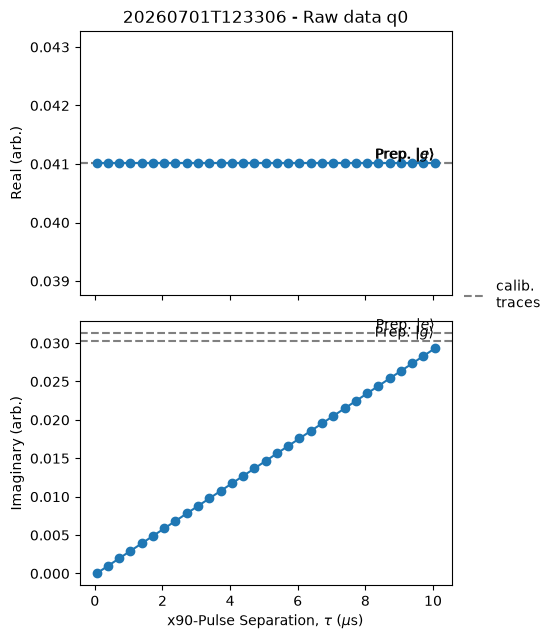

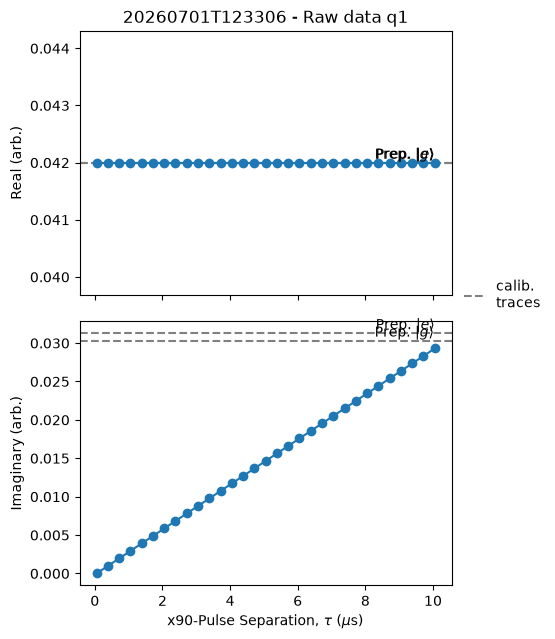

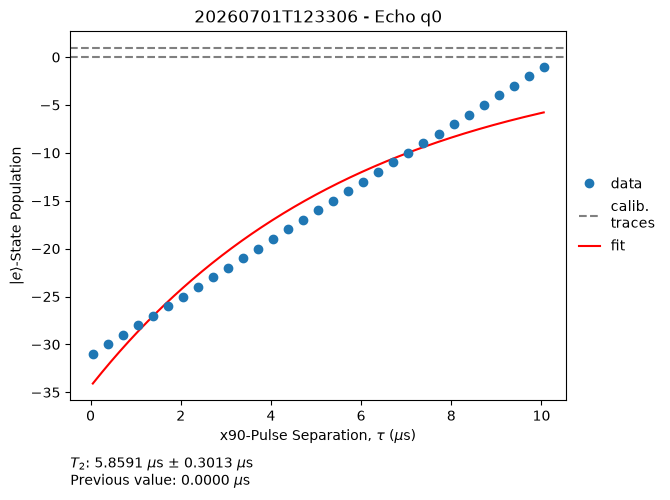

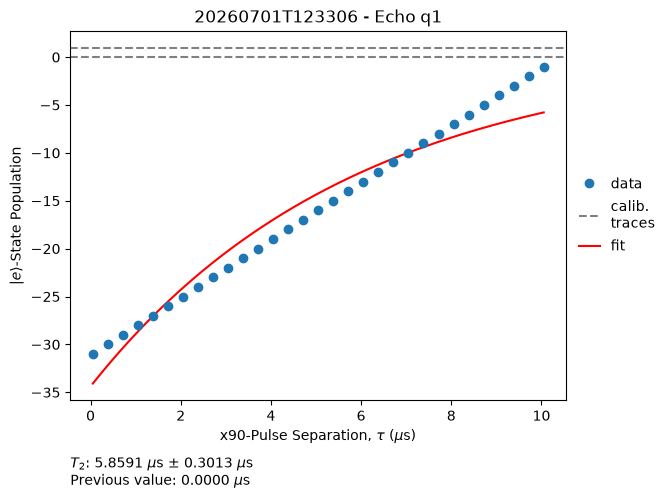

In [16]:
# our qubits live here in the demo setup:
qubits = qpu.quantum_elements

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[qubits[0].uid, qubits[1].uid],
    delays=[np.linspace(0, 10e-6, 31), np.linspace(0, 10e-6, 31)],
    options=options,
)

workflow_results = exp_workflow.run()

#### Inspect the Tasks That Were Run

In [17]:
for t in workflow_results.tasks:
    print(t)

TaskResult(name=temporary_qpu, index=())
TaskResult(name=temporary_quantum_elements_from_qpu, index=())
TaskResult(name=create_experiment, index=())
TaskResult(name=compile_experiment, index=())
TaskResult(name=run_experiment, index=())
WorkflowResult(name=analysis_workflow, index=())


#### Inspect the Output Simulation

You can also inspect the compiled experiment and plot the simulated output:

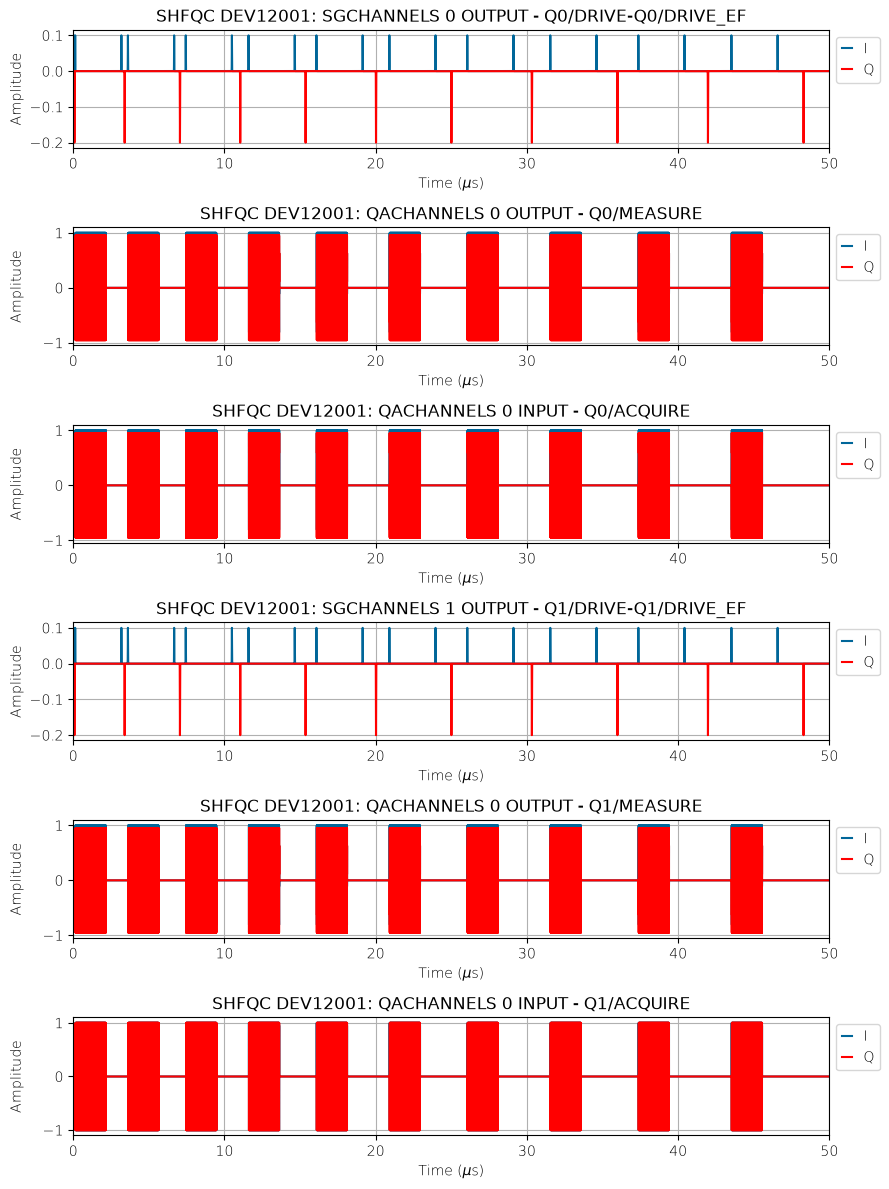

In [18]:
compiled_experiment = workflow_results.tasks["compile_experiment"].output
plot_simulation(compiled_experiment, length=50e-6)

#### Inspecting the Source Code of the Pulse-Sequence Creation Task

You can inspect the source code of the `create_experiment` task defined in `echo` to see how the experiment pulse sequence is created using quantum operations. To learn more about the latter, see the [Quantum Operations tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/quantum_operations.html).

In [19]:
echo.create_experiment.src

'@workflow.task\n@dsl.qubit_experiment\ndef create_experiment(\n    qpu: QPU,\n    qubits: QuantumElements,\n    delays: QubitSweepPoints,\n    options: EchoExperimentOptions | None = None,\n) -> Experiment:\n    """Creates a Hahn echo Experiment.\n\n    Arguments:\n        qpu:\n            The qpu consisting of the original qubits and quantum operations.\n        qubits:\n            The qubits on which to run the experiments. May be either a single\n            qubit or a list of qubits.\n        delays:\n            The delays to sweep over for each qubit. The delays between the two x90\n            pulses and the refocusing pulse are `delays / 2`; see the schematic of\n            the pulse sequence at the top of the file. Note that `delays` must be\n            identical for qubits that use the same measure port.\n        options:\n            The options for building the workflow as an instance of\n            [EchoExperimentOptions], inheriting from [TuneupExperimentOptions].\n            See the docstrings of these classes for more details.\n\n    Returns:\n        Experiment:\n            The generated LabOne Q Experiment instance to be compiled and executed.\n\n    Raises:\n        ValueError:\n            If the conditions in validation.validate_and_convert_qubits_sweeps are not\n            fulfilled.\n\n        ValueError:\n            If the experiment uses calibration traces and the averaging mode is\n            sequential.\n\n    Example:\n        ```python\n        options = TuneupExperimentOptions()\n        options.count = 10\n        options.cal_traces = True\n        setup = DeviceSetup("my_device")\n        qpu = QPU(\n            quantum_elements=[TunableTransmonQubit("q0"), TunableTransmonQubit("q1")],\n            quantum_operations=TunableTransmonOperations(),\n        )\n        temp_qubits = qpu.copy_quantum_elements()\n        create_experiment(\n            qpu=qpu,\n            qubits=temp_qubits,\n            delays=[np.linspace(0, 30e-6, 51), np.linspace(0, 30e-6, 51)],\n            options=options,\n        )\n        ```\n    """\n    # Define the custom options for the experiment\n    opts = EchoExperimentOptions() if options is None else options\n\n    qubits, delays = validation.validate_and_convert_qubits_sweeps(qubits, delays)\n    if (\n        opts.use_cal_traces\n        and AveragingMode(opts.averaging_mode) == AveragingMode.SEQUENTIAL\n    ):\n        raise ValueError(\n            "\'AveragingMode.SEQUENTIAL\' (or {AveragingMode.SEQUENTIAL}) cannot be used "\n            "with calibration traces because the calibration traces are added "\n            "outside the sweep."\n        )\n\n    delays_sweep_pars = [\n        SweepParameter(f"delays_{q.uid}", q_delays, axis_name=f"{q.uid}")\n        for q, q_delays in zip(qubits, delays, strict=False)\n    ]\n    qop = qpu.quantum_operations\n    # We will fix the length of the measure section to the longest section among\n    # the qubits to allow the qubits to have different readout and/or\n    # integration lengths.\n    max_measure_section_length = qop.measure_section_length(qubits)\n    with dsl.acquire_loop_rt(\n        count=opts.count,\n        averaging_mode=opts.averaging_mode,\n        acquisition_type=opts.acquisition_type,\n        repetition_mode=opts.repetition_mode,\n        repetition_time=opts.repetition_time,\n        reset_oscillator_phase=opts.reset_oscillator_phase,\n    ):\n        with dsl.sweep(\n            name="echo_sweep",\n            parameter=delays_sweep_pars,\n        ):\n            if opts.active_reset:\n                qop.active_reset(\n                    qubits,\n                    active_reset_states=opts.active_reset_states,\n                    number_resets=opts.active_reset_repetitions,\n                    measure_section_length=max_measure_section_length,\n                )\n            with dsl.section(name="main", alignment=SectionAlignment.RIGHT):\n                with dsl.section(name=

To learn more about how to work with experiment `Workflows`, check out the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html).

Here, let's briefly inspect the analysis-workflow results.

#### Analysis Results

Let's check what tasks were run as part of the analysis workflow:

In [20]:
analysis_workflow_results = workflow_results.tasks["analysis_workflow"]
for t in analysis_workflow_results.tasks:
    print(t)

TaskResult(name=calculate_qubit_population, index=())
TaskResult(name=fit_data, index=())
TaskResult(name=extract_qubit_parameters, index=())
TaskResult(name=plot_raw_complex_data_1d, index=())
TaskResult(name=plot_population, index=())


We can access the qubit parameters extracted by the analysis from the output of the analysis-workflow:

In [21]:
from pprint import pprint

pprint(analysis_workflow_results.output)

{'new_parameter_values': {'q0': {'ge_T2': 5.859146485398279e-06+/-3.012871968395437e-07},
                          'q1': {'ge_T2': 5.859146485398279e-06+/-3.012871968395437e-07}},
 'old_parameter_values': {'q0': {'ge_T2': 0}, 'q1': {'ge_T2': 0}}}


Check out the [Experiment Workflows tutorial](https://docs.zhinst.com/labone_q_user_manual/applications_library/tutorials/sources/experiment_workflows.html) to see how you can manually update the qubit parameters to these new values, or reset them to the old ones. 

Great! You've now run your echo experiment. Check out other experiments in this manual to keep characterizing your qubits.